<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Validation Legacy 4: Solar-To-Detector Pipeline
---

This notebook validates the complete solar neutrino pipeline: production in the solar interior, decoherence over the Sun–Earth distance, and Earth matter regeneration along detector trajectories. The full two-step factorisation (`solar_probability_mass` → `pearth`) is compared against the equivalent legacy Peanuts chain.

## Table of Contents

| Section | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** - solar production, decoherence, Earth regeneration, pipeline factorisation |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** - notebook paths, physical parameters |
| [3](#3.-Solar-to-Detector-Grid-Comparison) | **Solar-to-Detector Grid Comparison** - 20-point (E, eta) grid |
| [4](#4.-Energy-and-Nadir-Angle-Probability-Profiles) | **Energy and Nadir-Angle Probability Profiles** |
| [5](#5.-Exposure-Integrated-Probability) | **Exposure-Integrated Probability** - isotropic sky average |
| [6](#6.-Precision-Mode-Diagnostic) | **Precision Mode Diagnostic** - full vs legacy precision comparison |
| [7](#7.-Solar-Detector-Flux-Propagation) | **Solar-Detector Flux Propagation** - source spectrum propagated to detector flux |
| [8](#8.-Export-Results) | **Export Results** |
| [9](#9.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Solar Production Stage

A solar neutrino is produced as a pure flavour eigenstate $\nu_e$ with radial probability density $f_s(r)$ for source $s$. It propagates outward through the solar MSW potential *(Wolfenstein 1978; Mikheyev & Smirnov 1985)* and exits the Sun as a superposition of mass eigenstates. In the adiabatic limit (valid for LMA above $\sim$2 MeV), the mass-eigenstate populations at the solar surface are

$$P_i^\odot(E) = \int_0^{R_\odot} f_s(r)\,T_{ei}(E,\,r)\,\mathrm{d}r,$$

where $T_{ei}$ is the adiabatic transition amplitude from $\nu_e$ to mass eigenstate $\nu_i$ at production radius $r$.

---

### 0.2 Decoherence over the Sun–Earth Baseline

After leaving the Sun, the neutrino wave packet travels $\sim 1$ AU. At solar-neutrino energies (0.1–20 MeV), the coherence length of the mass-eigenstate wave packets satisfies *(Stodolsky 1975)*

$$L_{\rm coh} \sim \frac{2\pi E}{\Delta m^2}\cdot\frac{E}{\sigma_E} \ll 1\,\mathrm{AU},$$

so the three wave packets are fully separated before reaching the Earth. The quantum state arriving at the Earth is therefore an **incoherent mixture** of mass eigenstates with probabilities $P_i^\odot(E)$: there are no cross terms between different mass eigenstates.

---

### 0.3 Earth Regeneration Stage

Inside the Earth, coherence is re-established through the terrestrial matter potential. For an incoherent input with weights $P_i^\odot$, the detector flavour probability is *(Baltz & Weneser 1987)*

$$P_\alpha^{\rm det}(E,\eta) = \sum_{i=1}^{3} \left|S^\oplus_{\alpha i}(E,\eta)\right|^2 P_i^\odot(E),$$

where $S^\oplus(E,\eta)$ is the Earth evolution operator for nadir angle $\eta$ and energy $E$ from the PREM density profile.

---

### 0.4 Exposure-Integrated Probability

For detectors with full sky coverage (SNO, Borexino), the observable is the nadir-angle average:

$$\bar{P}_\alpha(E) = \frac{1}{2}\int_0^\pi P_\alpha^{\rm det}(E,\eta)\,\sin\eta\,\mathrm{d}\eta.$$

Numerically, this is computed via trapezoidal integration over a uniform $\eta$ grid (41 points).

---

### 0.5 Validation Strategy and Precision Mode

The pipeline is validated at 20 sample points (5 energies × 4 nadir angles) in both the $\nu_e$-survival and flavour-appearance channels, plus the exposure-integrated probability at 5 energies. The `LEGACY_PRECISION` flag applies consistently to both propagation steps. The precision diagnostic (Section 6) isolates the matter-potential prefactor difference between TPeanuts and legacy Peanuts over a fine energy scan.

---

**References**

- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369.
- Mikheyev, S. P. & Smirnov, A. Yu. (1985). *Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos*. Sov. J. Nucl. Phys. **42**, 913.
- Stodolsky, L. (1975). *Matter and energy effects in neutrino oscillations*. Phys. Rev. D **36**, 2273.
- Baltz, A. J. & Weneser, J. (1987). *Effect of transmission through the Earth on neutrino oscillations*. Phys. Rev. D **35**, 528.
- Ahmad, Q. R. et al. (SNO Collaboration, 2002). *Direct evidence for neutrino flavor transformation from neutral-current interactions in the Sudbury Neutrino Observatory*. Phys. Rev. Lett. **89**, 011301.
- Bellini, G. et al. (Borexino Collaboration, 2011). *Precision measurement of the $^7$Be solar neutrino interaction rate in Borexino*. Phys. Rev. Lett. **107**, 141302.
- Esteban, I. et al. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.

## 1. Libraries


In [37]:
from __future__ import annotations

import math

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_COLORS,
    FLAVOUR_INDEX,
    FLAVOUR_LABELS,
    FLAVOUR_NAMES,
    REL_FLOOR,
    TOL_PPB,
    TOL_PPM,
    abs_rel_delta,
    add_tolerance_lines,
    plot_tripanel,
    save_and_show,
    status_from_rel,
    summarize_validation,
    to_numpy,
)
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import pearth
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.solar.profile import SolarParameters, SolarProfile
from tpeanuts.medium.solar.validation import legacy_modules
from tpeanuts.pipeline.pipeline_legacypeanuts import _ensure_legacy_default_data_aliases
from tpeanuts.util.context import RuntimeContext
from peanuts.earth import Pearth as legacy_pearth
from peanuts.earth import earthdensity as LegacyEarthDensity
from peanuts.pmns import PMNS as LegacyPMNS

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/legacy/solar_detector_pipeline/`.

In [38]:
config = load_notebook_config()
_ensure_legacy_default_data_aliases()

PROJECT_DIR = config.package_dir
VALIDATION_ROOT = config.output_dir("validation", "legacy")
LEGACY_DATA_DIR = config.legacy_data_dir
OUTPUT_DIR = VALIDATION_ROOT / "solarneutrino_detector_pipeline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EARTH_DENSITY_FILE = str(config.earth_density_file)
LEGACY_EARTH_DENSITY_FILE = str(LEGACY_DATA_DIR / "earth_density.csv")
SPECTRUM_FILES = {
    "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
    "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
    "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
    "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
    "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
    "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
    "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
    "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
}
SOLAR_MODEL_FILE = str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat")
SOLAR_FLUX_FILE = str(LEGACY_DATA_DIR / "fluxes_b16.dat")
SOLAR_MODEL_CSV_FILE = str(config.data_dir / "solar" / "nudistr_b16_agss09.csv")
SOLAR_FLUX_CSV_FILE = str(config.data_dir / "solar" / "fluxes_b16.csv")

print(f"Project directory: {PROJECT_DIR}")
print(f"Legacy data dir  : {LEGACY_DATA_DIR}")
print(f"Torch solar model: {SOLAR_MODEL_CSV_FILE}")
print(f"Torch solar flux : {SOLAR_FLUX_CSV_FILE}")
print(f"Validation root  : {VALIDATION_ROOT}")
print(f"Output directory : {OUTPUT_DIR}")

Project directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Legacy data dir  : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Torch solar model: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\nudistr_b16_agss09.csv
Torch solar flux : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\fluxes_b16.csv
Validation root  : v:\output\validation\legacy
Output directory : v:\output\validation\legacy\solarneutrino_detector_pipeline


### 2.2 Configuration

The pipeline validation uses $^8$B as the solar source and Super-Kamiokande-like detector depth (1 km underground). The energy range 0.5–15 MeV covers the full $^8$B spectrum.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| Solar source | $^8$B | Dominant source for SK/SNO detectors |
| Solar model | B16 AGSS09 | Standard Solar Model (Vinyoles et al. 2017) |
| Earth density | PREM (tabulated) | Dziewonski & Anderson 1981 |
| Detector depth | 1 000 m | Underground detector |
| Earth propagation | Analytical | Piecewise constant-density shells |
| Energy grid | 90 pts, 0.5–15 MeV | Linear spacing |
| Nadir grid | 90 pts | For profile and exposure integrals |
| Exposure grid | 41 pts | Trapezoidal quadrature for $\bar{P}_\alpha$ |
| Sample energies | 1, 3, 5, 8, 12 MeV | Grid-comparison points |
| Sample nadir angles | 0.35, 0.75, 1.20, 2.40 rad | Mantle to core trajectories |
| `LEGACY_PRECISION` | `False` | Full-precision $G_F$ for ordinary sections |

In [39]:
SHOW_PLOTS = config.show_plots
DEVICE = config.device
DTYPE = config.dtype
CDTYPE = torch.complex128
context = RuntimeContext.resolve(DEVICE, DTYPE)
LEGACY_PRECISION = True

oscillation = OscillationParameters.from_preset(context=context, antinu=False)
pmns = oscillation.pmns
THETA12 = float(pmns.params.theta12.detach().cpu())
THETA13 = float(pmns.params.theta13.detach().cpu())
THETA23 = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.DeltamSq3l.detach().cpu())

legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)
solar_profile = SolarProfile.default(
    params=SolarParameters(
        model_path=SOLAR_MODEL_CSV_FILE,
        fluxes_path=SOLAR_FLUX_CSV_FILE,
    ),
    context=context,
)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)
profile_earth = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={"density_file": EARTH_DENSITY_FILE, "tabulated_density": False},
    ),
    context=context,
)
legacy_earth = LegacyEarthDensity(density_file=LEGACY_EARTH_DENSITY_FILE, tabulated_density=False)
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=SOLAR_MODEL_FILE,
    flux_file=SOLAR_FLUX_FILE,
    spectrum_files=SPECTRUM_FILES,
)
SOLAR_SOURCE = "8B"
DETECTOR_DEPTH_M = 1000.0
EARTH_METHOD = "analytical"
EXPOSURE_NS = 41
SD_ENERGY_GRID = torch.linspace(0.5, 15.0, 90, dtype=DTYPE, device=DEVICE)
SD_ETA_GRID = torch.linspace(0.05, math.pi - 0.05, 90, dtype=DTYPE, device=DEVICE)
SD_ETA_FIXED = torch.tensor(0.75, dtype=DTYPE, device=DEVICE)
SD_SAMPLE_ENERGIES_MEV = [1.0, 3.0, 5.0, 8.0, 12.0]
SD_SAMPLE_ETA_RAD = [0.35, 0.75, 1.20, 2.40]
SD_ETA_PLOT_ENERGY_MEV = torch.tensor(5.0, dtype=DTYPE, device=DEVICE)
SD_INTEGRATION_ENERGY_GRID_MEV = torch.tensor([1.0, 3.0, 5.0, 8.0, 12.0], dtype=DTYPE, device=DEVICE)
SD_INTEGRATION_ETA_GRID = torch.linspace(0.02, math.pi - 0.02, EXPOSURE_NS, dtype=DTYPE, device=DEVICE)
SD_INTEGRATION_EXPOSURE = torch.ones_like(SD_INTEGRATION_ETA_GRID)
SD_INTEGRATION_EXPOSURE = SD_INTEGRATION_EXPOSURE / torch.trapezoid(
    SD_INTEGRATION_EXPOSURE, x=SD_INTEGRATION_ETA_GRID
).clamp_min(torch.finfo(DTYPE).tiny)

print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")
print("System and simulation parameters loaded.")

Oscillation preset: _SM_NUFIT52_NO (NO)
System and simulation parameters loaded.


### 2.3. Pipeline Function Wrappers

Four functions implement the two-step solar-to-detector pipeline for both TPeanuts and legacy Peanuts:

- `solar_mass_t(E_MeV)` — TPeanuts mass-eigenstate probability at the solar surface for source $^8$B at energy $E$.
- `solar_mass_l(E_MeV)` — Legacy equivalent using `solar_flux_mass`.
- `earth_from_mass_t(w, E, η)` — TPeanuts Earth regeneration for mass-weight vector $\mathbf{w}$, energy $E$, and nadir angle $\eta$.
- `earth_from_mass_l(w, E, η)` — Legacy equivalent using `Pearth`.

The combined probability at the detector after both steps is

$$P_\alpha^\text{det}(E,\eta) = \sum_{i} \left[U_\oplus(E,\eta)\right]_{\alpha i}\,P_i^\text{solar}(E)$$

where $U_\oplus$ is the Earth evolution operator in the mass basis and $P_i^\text{solar}$ is the mass-eigenstate population from solar propagation. This two-step factorisation is exact when the neutrino coherence length is much smaller than the Sun–Earth distance, which is satisfied for solar neutrinos in the MeV range.

In [40]:
def solar_mass_t(E_MeV, *, legacy_precision=None):
    precision_flag = LEGACY_PRECISION if legacy_precision is None else legacy_precision
    return solar_probability_mass(oscillation, E_MeV, solar_profile, SOLAR_SOURCE, legacy_precision=precision_flag)


def solar_mass_l(E_MeV: float):
    return legacy_solar_module.solar_flux_mass(legacy_pmns_solar.theta12, legacy_pmns_solar.theta13, DM21_EV2, DM3L_EV2, float(E_MeV), legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE))


def earth_from_mass_t(mass_weights, E_MeV, eta_rad, *, legacy_precision=None):
    precision_flag = LEGACY_PRECISION if legacy_precision is None else legacy_precision
    return pearth(
        torch.as_tensor(mass_weights, device=DEVICE),
        profile_earth,
        oscillation,
        torch.as_tensor(E_MeV, device=DEVICE, dtype=DTYPE),
        torch.as_tensor(eta_rad, device=DEVICE, dtype=DTYPE),
        DETECTOR_DEPTH_M,
        massbasis=True,
        method=EARTH_METHOD,
        context=context,
        legacy_precision=precision_flag,
    )


def earth_from_mass_l(mass_weights, E_MeV: float, eta_rad: float):
    return legacy_pearth(mass_weights, legacy_earth, legacy_pmns, DM21_EV2, DM3L_EV2, float(E_MeV), float(eta_rad), DETECTOR_DEPTH_M, mode=EARTH_METHOD, massbasis=True)

## 3. Solar-to-Detector Grid Comparison

The full pipeline is evaluated at a grid of 5 energies x 4 nadir angles = 20 parameter points, with 3 final flavours each (60 rows). The computed relative difference combines contributions from both the solar and Earth steps: the solar step carries the matter-potential prefactor sensitivity from notebook 2, while the Earth step is tested separately in notebook 3.

The code immediately below performs this grid comparison using the wrappers from Section 2.3. Ordinary execution uses `LEGACY_PRECISION`; Section 6 later compares both precision modes explicitly.

In [41]:

rows = []
for energy in SD_SAMPLE_ENERGIES_MEV:
    mass_candidate = solar_mass_t(torch.tensor(energy, dtype=DTYPE, device=DEVICE))
    mass_reference = solar_mass_l(energy)
    for eta in SD_SAMPLE_ETA_RAD:
        candidate = earth_from_mass_t(mass_candidate, energy, eta)
        reference = earth_from_mass_l(mass_reference, energy, eta)
        abs_delta, rel_delta = abs_rel_delta(candidate, reference)
        for final_name, alpha in FLAVOUR_INDEX.items():
            rows.append({"medium": "solar_detector_pipeline", "observable": "probability", "source": SOLAR_SOURCE, "E_MeV": energy, "eta_rad": eta, "depth_m": DETECTOR_DEPTH_M, "final_flavour": final_name, "candidate": to_numpy(candidate)[alpha], "reference": to_numpy(reference)[alpha], "abs_delta": abs_delta[alpha], "rel_delta": rel_delta[alpha]})
pipeline_probability_table = pd.DataFrame(rows)
pipeline_probability_summary = summarize_validation(pipeline_probability_table, ["medium", "observable", "eta_rad"])
display(pipeline_probability_summary)


,medium,observable,eta_rad,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,solar_detector_pipeline,probability,0.35,15,9.259057e-10,1.005349e-10,2.493444e-10,2.597100e-09,3.230163e-10,7.538296e-10,0.196273,0.317113
1,solar_detector_pipeline,probability,0.75,15,4.430206e-10,1.324359e-10,1.504126e-10,1.354275e-09,4.170541e-10,4.503041e-10,0.196216,0.322962
2,solar_detector_pipeline,probability,1.20,15,2.057210e-10,4.139644e-11,5.670534e-11,6.171384e-10,1.036067e-10,1.717193e-10,0.196269,0.324855
3,solar_detector_pipeline,probability,2.40,15,1.476597e-14,2.886580e-15,4.411286e-15,2.832153e-14,1.146873e-14,1.268008e-14,0.196200,0.325393


## 4. Energy and Nadir-Angle Probability Profiles

The following profiles diagnose the two most important dependencies of the detector probability: energy, which controls the solar MSW transition, and nadir angle, which controls the amount of Earth matter crossed before detection.

### 4.1 Energy Dependence

The detector probability is scanned from 0.5 MeV to 15 MeV at fixed nadir angle. This covers the configured 8B range and checks that the solar MSW transition is propagated consistently through the Earth-regeneration step.

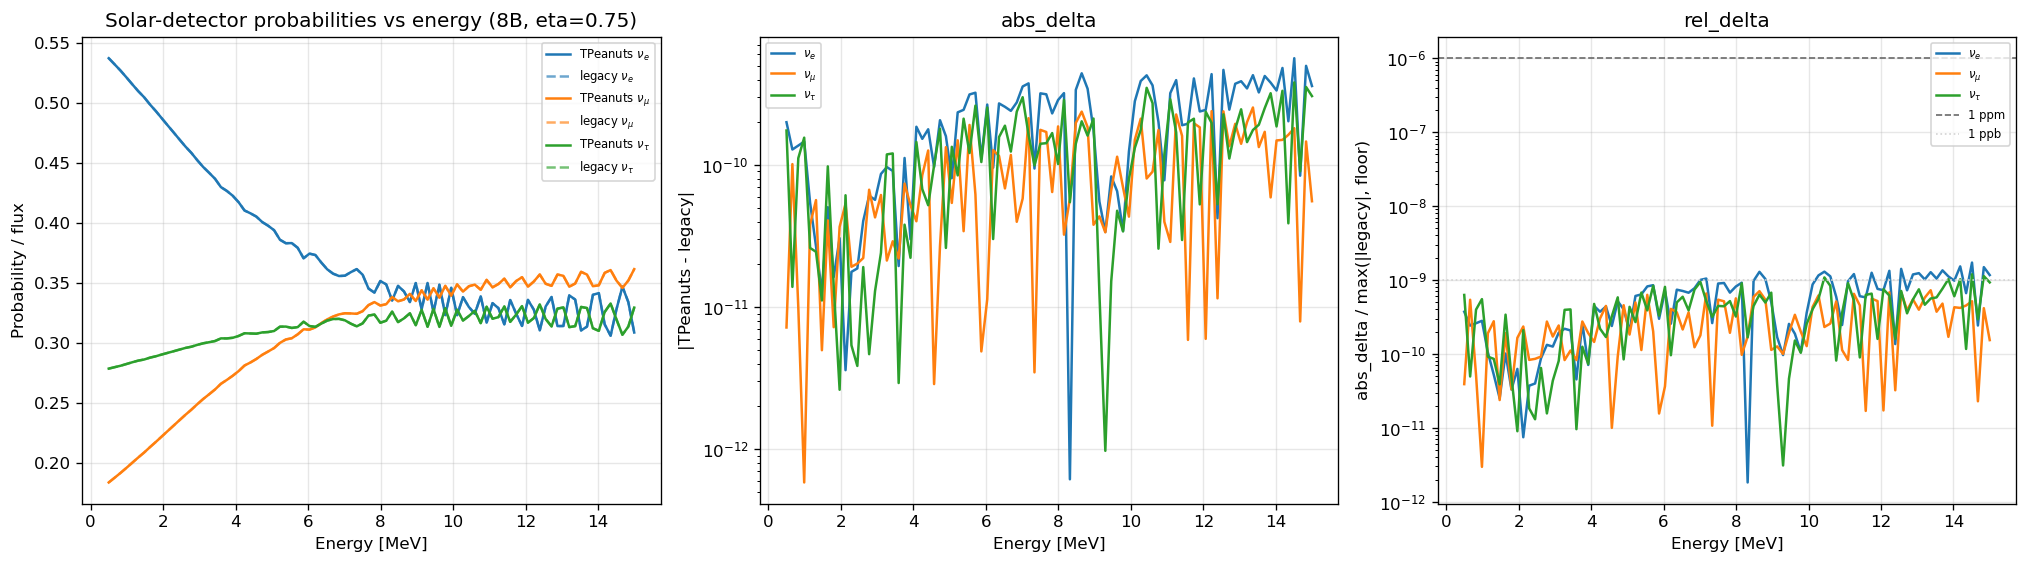

v:\output\validation\legacy\solarneutrino_detector_pipeline\validation_legacy4_pipeline_probability_vs_energy.png


In [42]:
mass_grid_t = solar_mass_t(SD_ENERGY_GRID)
prob_e_t, prob_e_l = [], []
for i, energy in enumerate(SD_ENERGY_GRID):
    prob_e_t.append(earth_from_mass_t(mass_grid_t[i], energy, SD_ETA_FIXED))
    prob_e_l.append(earth_from_mass_l(solar_mass_l(float(energy)), float(energy), float(SD_ETA_FIXED)))
prob_e_t = torch.stack(prob_e_t, dim=0)
prob_e_l = np.stack(prob_e_l, axis=0)
plot_tripanel(
    SD_ENERGY_GRID,
    prob_e_t,
    prob_e_l,
    title=f"Solar-detector probabilities vs energy ({SOLAR_SOURCE}, eta={float(SD_ETA_FIXED):.2f})",
    xlabel="Energy [MeV]",
    filename="validation_legacy4_pipeline_probability_vs_energy.png",
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)

### 4.2 Nadir-Angle Dependence

The detector probability is scanned vs nadir angle at fixed energy. This tests the Earth-regeneration component for trajectories ranging from shallow mantle paths to long Earth-crossing paths.

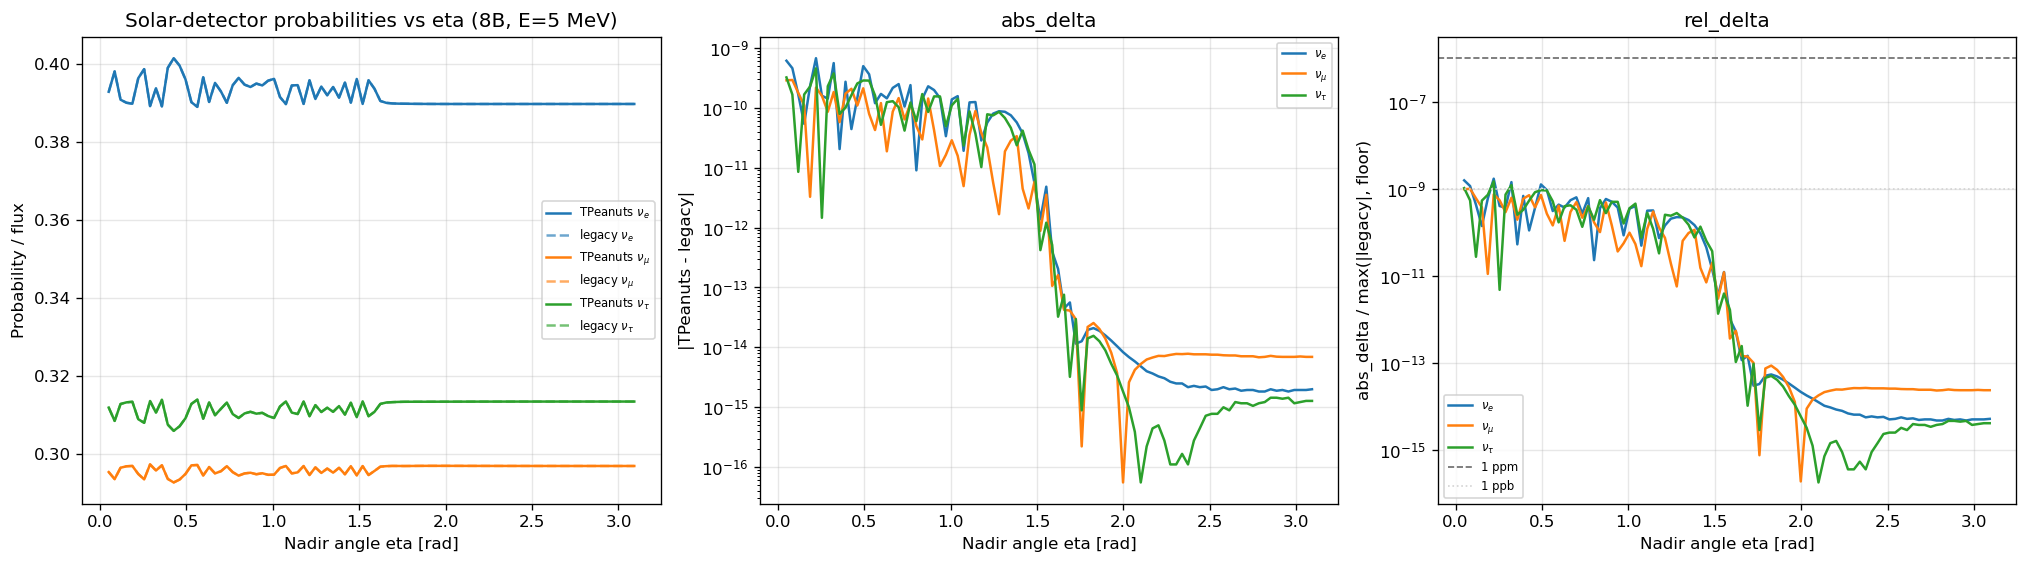

v:\output\validation\legacy\solarneutrino_detector_pipeline\validation_legacy4_pipeline_probability_vs_eta.png


In [43]:
mt_eta = solar_mass_t(SD_ETA_PLOT_ENERGY_MEV)
ml_eta = solar_mass_l(float(SD_ETA_PLOT_ENERGY_MEV))
prob_eta_t = torch.stack([earth_from_mass_t(mt_eta, SD_ETA_PLOT_ENERGY_MEV, eta) for eta in SD_ETA_GRID], dim=0)
prob_eta_l = np.stack([earth_from_mass_l(ml_eta, float(SD_ETA_PLOT_ENERGY_MEV), float(eta)) for eta in to_numpy(SD_ETA_GRID)], axis=0)
plot_tripanel(
    SD_ETA_GRID,
    prob_eta_t,
    prob_eta_l,
    title=f"Solar-detector probabilities vs eta ({SOLAR_SOURCE}, E=5 MeV)",
    xlabel="Nadir angle eta [rad]",
    filename="validation_legacy4_pipeline_probability_vs_eta.png",
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)

## 5. Exposure-Integrated Probability

Detectors like SNO, Borexino, and Super-Kamiokande are sensitive to solar neutrinos arriving from all directions uniformly (isotropic sky). The effective detector probability, averaged over the full sky exposure, is

$$\langle P_\alpha^\text{det}(E) \rangle = \frac{1}{\mathcal{N}} \int_0^\pi P_\alpha^\text{det}(E,\eta)\,d\eta, \qquad \mathcal{N} = \int_0^\pi d\eta$$

(uniform weight in nadir angle). This quantity is evaluated at 5 energies ($1, 3, 5, 8, 12\,\text{MeV}$) using the trapezoidal rule over 41 nadir-angle points. Earth regeneration is included; for $^8$B the regeneration effect is small (a few percent increase in $P_{ee}$ for core-crossing trajectories at $E \sim 5\,\text{MeV}$) but grows at lower energies where the vacuum mixing is larger.

**Expected Results:** Both implementations should agree to $\sim 10^{-4}$ in relative error after integration. Integration over $\eta$ should not introduce additional discrepancy beyond what is already present point-by-point. The three-panel plot confirms that the exposure-averaging procedure is numerically equivalent between the two codes.

,medium,observable,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,solar_detector_pipeline,integrated_probability,15,4.281675e-11,1.518113e-11,1.591844e-11,1.094767e-10,4.354069e-11,4.667453e-11,0.196266,0.322251


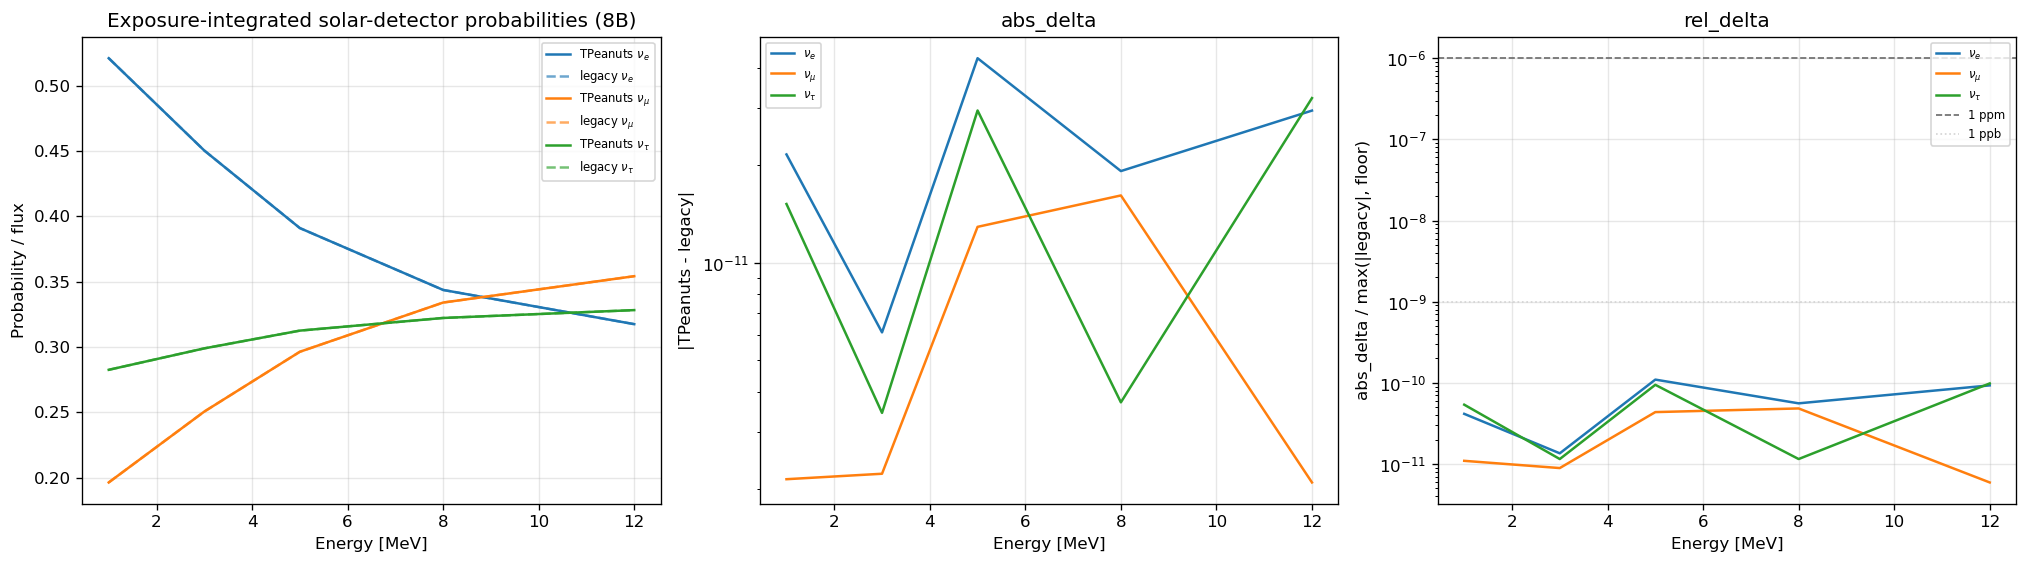

v:\output\validation\legacy\solarneutrino_detector_pipeline\validation_legacy4_pipeline_integrated_probability.png


In [44]:

P_sd_int_t, P_sd_int_l = [], []
for energy in SD_INTEGRATION_ENERGY_GRID_MEV:
    mt = solar_mass_t(energy)
    ml = solar_mass_l(float(energy))
    row_t = torch.stack([earth_from_mass_t(mt, energy, eta) for eta in SD_INTEGRATION_ETA_GRID], dim=0)
    row_l = np.stack([earth_from_mass_l(ml, float(energy), float(eta)) for eta in to_numpy(SD_INTEGRATION_ETA_GRID)], axis=0)
    P_sd_int_t.append(torch.trapezoid(row_t * SD_INTEGRATION_EXPOSURE[:, None], x=SD_INTEGRATION_ETA_GRID, dim=0))
    P_sd_int_l.append(np.trapz(row_l * to_numpy(SD_INTEGRATION_EXPOSURE)[:, None], x=to_numpy(SD_INTEGRATION_ETA_GRID), axis=0))
P_sd_int_t = torch.stack(P_sd_int_t, dim=0)
P_sd_int_l = np.stack(P_sd_int_l, axis=0)
abs_int, rel_int = abs_rel_delta(P_sd_int_t, P_sd_int_l)
integrated_rows = []
for i, energy in enumerate(to_numpy(SD_INTEGRATION_ENERGY_GRID_MEV)):
    for final_name, alpha in FLAVOUR_INDEX.items():
        integrated_rows.append({"medium": "solar_detector_pipeline", "observable": "integrated_probability", "source": SOLAR_SOURCE, "E_MeV": energy, "depth_m": DETECTOR_DEPTH_M, "final_flavour": final_name, "candidate": to_numpy(P_sd_int_t)[i, alpha], "reference": P_sd_int_l[i, alpha], "abs_delta": abs_int[i, alpha], "rel_delta": rel_int[i, alpha]})
integrated_probability_table = pd.DataFrame(integrated_rows)
display(summarize_validation(integrated_probability_table, ["medium", "observable"]))
plot_tripanel(SD_INTEGRATION_ENERGY_GRID_MEV, P_sd_int_t, P_sd_int_l, title=f"Exposure-integrated solar-detector probabilities ({SOLAR_SOURCE})", xlabel="Energy [MeV]", filename="validation_legacy4_pipeline_integrated_probability.png", output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Precision Mode Diagnostic

This diagnostic compares the full-precision default and the legacy-precision compatibility mode against the legacy Peanuts solar-to-detector reference over the configured detector energy grid at the fixed diagnostic nadir angle. The panels show probability values, absolute differences, and relative differences.

,mode,source,eta_rad,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,full_precision,8B,0.75,270,4.409489e-05,1.315089e-05,1.685029e-05,1.210548e-04,3.908010e-05,5.043813e-05,0.183868,0.326717
1,legacy_precision,8B,0.75,270,5.648897e-10,1.245226e-10,1.465952e-10,1.720410e-09,3.723055e-10,4.405104e-10,0.183868,0.326717


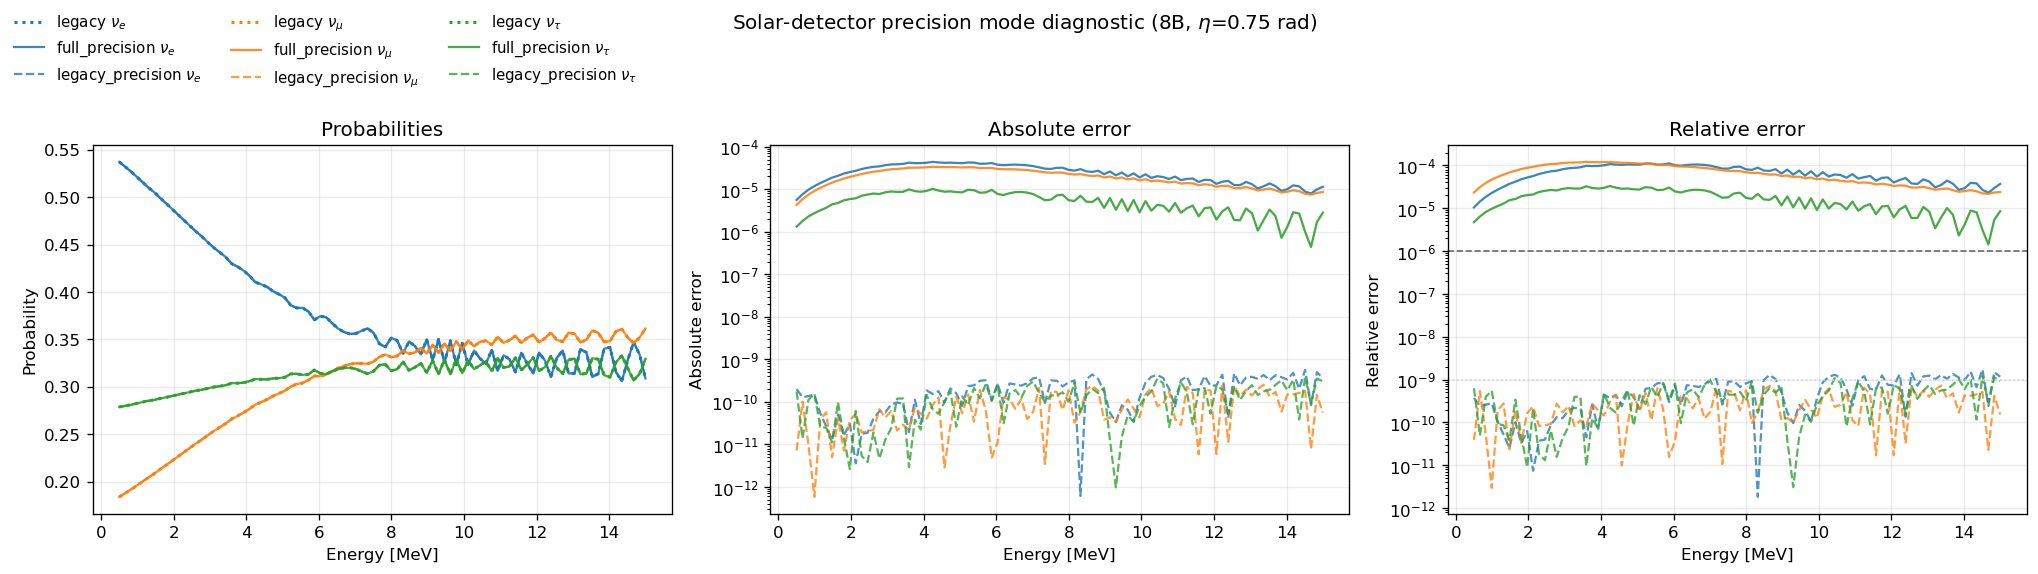

v:\output\validation\legacy\solarneutrino_detector_pipeline\validation_legacy4_pipeline_precision_modes_energy_scan.png


In [49]:
precision_modes = [("full_precision", False), ("legacy_precision", True)]
precision_energy_np = to_numpy(SD_ENERGY_GRID)
precision_eta_rad = float(SD_ETA_FIXED.detach().cpu())
precision_reference = np.stack([
    earth_from_mass_l(solar_mass_l(float(energy)), float(energy), precision_eta_rad)
    for energy in precision_energy_np
])

precision_rows = []
precision_scan_by_mode = {}
for mode_name, mode_flag in precision_modes:
    mass_scan = solar_mass_t(SD_ENERGY_GRID, legacy_precision=mode_flag)
    candidate_scan = torch.stack([
        earth_from_mass_t(mass_scan[i], energy, SD_ETA_FIXED, legacy_precision=mode_flag)
        for i, energy in enumerate(SD_ENERGY_GRID)
    ], dim=0)
    precision_scan_by_mode[mode_name] = candidate_scan
    abs_delta, rel_delta = abs_rel_delta(candidate_scan, precision_reference)
    candidate_np = to_numpy(candidate_scan)
    for i, energy in enumerate(precision_energy_np):
        for final_name, alpha in FLAVOUR_INDEX.items():
            precision_rows.append(
                {
                    "medium": "solar_detector_pipeline",
                    "observable": "pipeline_precision_mode",
                    "source": SOLAR_SOURCE,
                    "E_MeV": energy,
                    "eta_rad": precision_eta_rad,
                    "depth_m": DETECTOR_DEPTH_M,
                    "mode": mode_name,
                    "final_flavour": final_name,
                    "candidate": candidate_np[i, alpha],
                    "reference": precision_reference[i, alpha],
                    "abs_delta": abs_delta[i, alpha],
                    "rel_delta": rel_delta[i, alpha],
                    "legacy_precision": mode_flag,
                }
            )
precision_mode_table = pd.DataFrame(precision_rows)
precision_mode_summary = summarize_validation(precision_mode_table, ["mode", "source", "eta_rad"])
display(precision_mode_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True)
mode_styles = {"full_precision": "-", "legacy_precision": "--"}
mode_alphas = {"full_precision": 0.88, "legacy_precision": 0.78}
value_floor = 1.0e-300

for final_name, alpha in FLAVOUR_INDEX.items():
    label = FLAVOUR_LABELS[alpha]
    color = FLAVOUR_COLORS[alpha]
    axes[0].plot(precision_energy_np, precision_reference[:, alpha], color=color, linestyle=":", linewidth=1.8, label=f"legacy {label}")
    for mode_name, _ in precision_modes:
        candidate_scan = precision_scan_by_mode[mode_name]
        candidate_np = to_numpy(candidate_scan)
        abs_delta, rel_delta = abs_rel_delta(candidate_scan, precision_reference)
        axes[0].plot(precision_energy_np, candidate_np[:, alpha], color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")
        axes[1].semilogy(precision_energy_np, np.maximum(abs_delta[:, alpha], value_floor), color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")
        axes[2].semilogy(precision_energy_np, np.maximum(rel_delta[:, alpha], value_floor), color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")

axes[0].set_title("Probabilities")
axes[1].set_title("Absolute error")
axes[2].set_title("Relative error")
axes[0].set_ylabel("Probability")
axes[1].set_ylabel("Absolute error")
axes[2].set_ylabel("Relative error")
add_tolerance_lines(axes[2])
for ax in axes:
    ax.set_xlabel("Energy [MeV]")
    ax.grid(alpha=0.25)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=3, fontsize=9, frameon=False)
fig.suptitle(rf"Solar-detector precision mode diagnostic ({SOLAR_SOURCE}, $\eta$={precision_eta_rad:.2f} rad)", y=1.03)
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_and_show(
    "validation_legacy4_pipeline_precision_modes_energy_scan.png",
    fig,
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)


## 7. Solar-Detector Flux Propagation

This section validates the flux obtained after the complete solar-to-detector chain. The same solar source spectrum is applied to the TPeanuts and legacy probabilities,

$$\Phi_\alpha^\text{det}(E,\eta) = \Phi_\text{source}\, f_\text{source}(E)\, P_\alpha^\text{det}(E,\eta),$$

where $\Phi_\text{source}$ is the total source flux, $f_\text{source}(E)$ is the tabulated spectral shape, and $P_\alpha^\text{det}$ is the probability produced by the solar propagation plus Earth-regeneration pipeline.

This is the solar-detector analogue of the flux check in `validation_legacy1`: it verifies that the validated probability chain also produces consistent detector-level spectra when weighted by the source flux model.

**Expected Results:**
- The flux residuals should be controlled by the same differences observed in the pipeline probability comparison.
- Absolute differences scale with the source flux normalization and spectral shape, while relative differences remain the primary precision diagnostic.


,medium,observable,source,eta_rad,precision_mode,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,solarneutrino_detector_pipeline,flux,8B,0.75,legacy_precision,270,0.000217,0.00002,0.000042,1.528112e-09,3.391689e-10,4.061582e-10,0.0,104687.845551


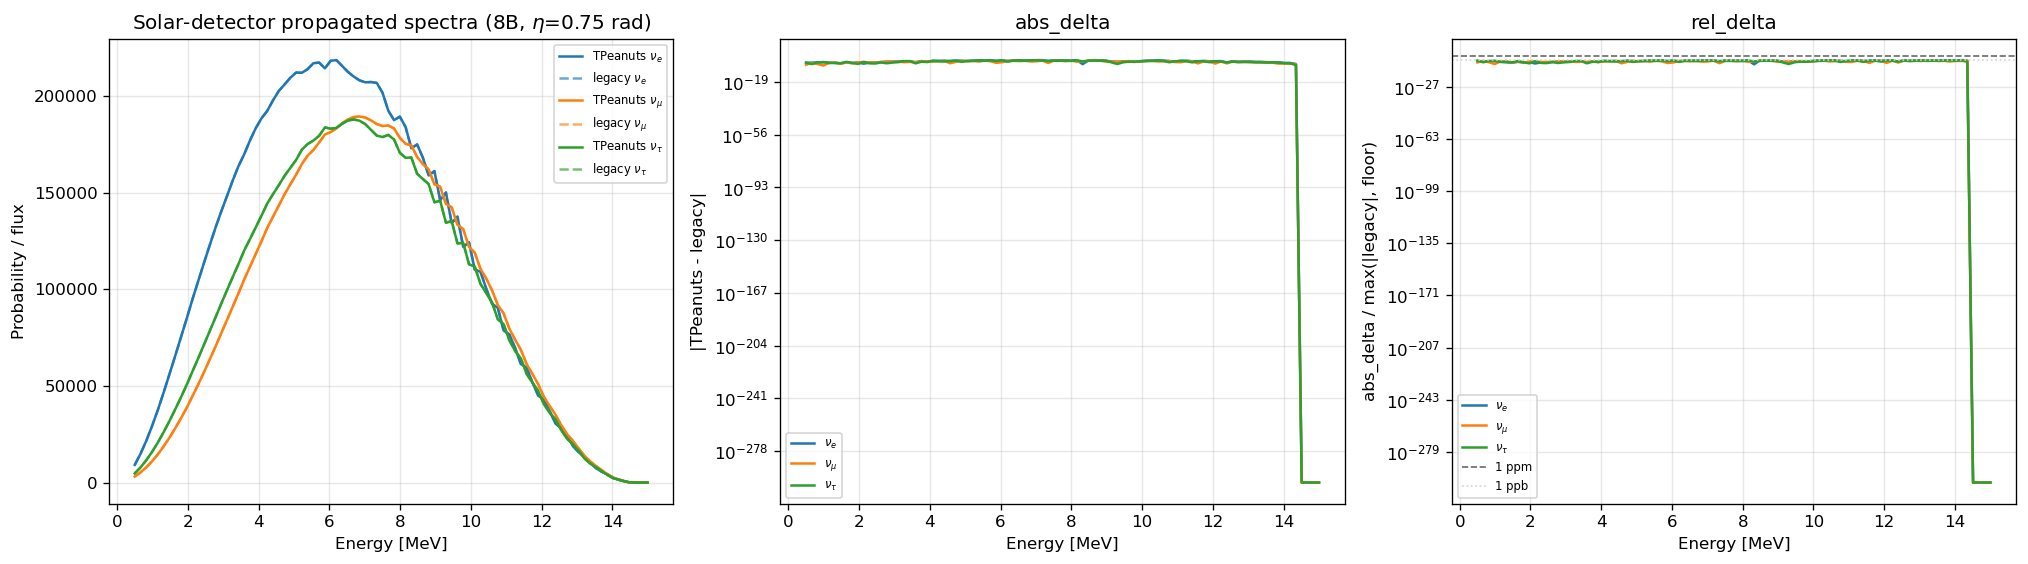

v:\output\validation\legacy\solarneutrino_detector_pipeline\validation_legacy4_pipeline_flux_scan.png


In [46]:
def solar_source_spectrum(energies_MeV) -> np.ndarray:
    return np.array([legacy_model.spectrum(SOLAR_SOURCE, float(energy)) for energy in to_numpy(energies_MeV)], dtype=float)


pipeline_flux_mode = "legacy_precision" if LEGACY_PRECISION else "full_precision"
pipeline_flux_eta_rad = precision_eta_rad
pipeline_flux_energy_np = precision_energy_np
pipeline_spectrum_np = solar_source_spectrum(SD_ENERGY_GRID)
pipeline_flux_norm_t = float(to_numpy(solar_profile.flux(SOLAR_SOURCE)))
pipeline_flux_norm_l = float(legacy_model.flux(SOLAR_SOURCE))

pipeline_probability_t = precision_scan_by_mode[pipeline_flux_mode]
pipeline_probability_l = precision_reference
pipeline_flux_scale_t = torch.as_tensor(
    pipeline_flux_norm_t * pipeline_spectrum_np,
    device=DEVICE,
    dtype=DTYPE,
)
pipeline_flux_t = pipeline_probability_t * pipeline_flux_scale_t[:, None]
pipeline_flux_l = pipeline_probability_l * (pipeline_flux_norm_l * pipeline_spectrum_np)[:, None]
abs_flux, rel_flux = abs_rel_delta(pipeline_flux_t, pipeline_flux_l)

flux_rows = []
for j, energy in enumerate(pipeline_flux_energy_np):
    for final_name, alpha in FLAVOUR_INDEX.items():
        flux_rows.append({
            "medium": "solarneutrino_detector_pipeline",
            "observable": "flux",
            "source": SOLAR_SOURCE,
            "E_MeV": energy,
            "eta_rad": pipeline_flux_eta_rad,
            "depth_m": DETECTOR_DEPTH_M,
            "precision_mode": pipeline_flux_mode,
            "final_flavour": final_name,
            "candidate": to_numpy(pipeline_flux_t)[j, alpha],
            "reference": pipeline_flux_l[j, alpha],
            "abs_delta": abs_flux[j, alpha],
            "rel_delta": rel_flux[j, alpha],
        })

pipeline_flux_table = pd.DataFrame(flux_rows)
display(summarize_validation(pipeline_flux_table, ["medium", "observable", "source", "eta_rad", "precision_mode"]))
plot_tripanel(
    SD_ENERGY_GRID,
    pipeline_flux_t,
    pipeline_flux_l,
    title=rf"Solar-detector propagated spectra ({SOLAR_SOURCE}, $\eta$={pipeline_flux_eta_rad:.2f} rad)",
    xlabel="Energy [MeV]",
    filename="validation_legacy4_pipeline_flux_scan.png",
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)


## 8. Export Results

Six CSV files are written to `VALIDATION_ROOT/solar_detector_pipeline/` for aggregation by the summary notebook:

- `validation_legacy4_pipeline_probability.csv` - per-row grid results (5 energy x 4 nadir x 3 flavour).
- `validation_legacy4_pipeline_probability_summary.csv` - max/median/mean delta grouped by nadir angle.
- `validation_legacy4_pipeline_integrated_probability.csv` - exposure-integrated probabilities at 5 energies x 3 flavours.
- `validation_legacy4_pipeline_precision_modes.csv` - full energy-grid comparison between full precision and legacy precision.
- `validation_legacy4_pipeline_precision_modes_summary.csv` - grouped summary of the precision-mode deltas.
- `validation_legacy4_pipeline_flux.csv` - detector-level flux comparison across the energy grid.

In [47]:

pipeline_probability_table.to_csv(OUTPUT_DIR / "validation_legacy4_pipeline_probability.csv", index=False)
pipeline_probability_summary.to_csv(OUTPUT_DIR / "validation_legacy4_pipeline_probability_summary.csv", index=False)
integrated_probability_table.to_csv(OUTPUT_DIR / "validation_legacy4_pipeline_integrated_probability.csv", index=False)
#precision_mode_table.to_csv(OUTPUT_DIR / "validation_legacy4_pipeline_precision_modes.csv", index=False)
#precision_mode_summary.to_csv(OUTPUT_DIR / "validation_legacy4_pipeline_precision_modes_summary.csv", index=False)
pipeline_flux_table.to_csv(OUTPUT_DIR / "validation_legacy4_pipeline_flux.csv", index=False)
print(OUTPUT_DIR)


v:\output\validation\legacy\solarneutrino_detector_pipeline


## 9. Summary

The final table collects the grid comparison, exposure-integrated comparison, explicit precision-mode diagnostic, and detector-level flux comparison for the complete solar-to-detector chain.

In [48]:
summary_tables = [
    ("pipeline grid", pipeline_probability_table),
    ("exposure integrated", integrated_probability_table),
    ("precision modes", precision_mode_table),
    ("pipeline flux", pipeline_flux_table),
]
summary_rows = []
for label, table in summary_tables:
    summary_rows.append({
        "check": label,
        "rows": len(table),
        "max_abs_delta": table["abs_delta"].max(),
        "max_rel_delta": table["rel_delta"].max(),
        "median_rel_delta": table["rel_delta"].median(),
        "status": status_from_rel(table["rel_delta"].max()),
    })
validation_summary = pd.DataFrame(summary_rows)
display(validation_summary)
print(f"Pipeline validation sections used LEGACY_PRECISION={LEGACY_PRECISION}; Section 6 intentionally compares both precision modes.")

,check,rows,max_abs_delta,max_rel_delta,median_rel_delta,status
0,pipeline grid,60,9.259057e-10,2.597100e-09,1.626837e-10,PASS < ppm
1,exposure integrated,15,4.281675e-11,1.094767e-10,4.354069e-11,PASS < ppb
2,precision modes,540,4.409489e-05,1.210548e-04,7.153854e-07,CHECK < 1e-3
3,pipeline flux,270,2.169898e-04,1.528112e-09,3.391689e-10,PASS < ppm


Pipeline validation sections used LEGACY_PRECISION=True; Section 6 intentionally compares both precision modes.
